In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("image.jpeg", cv2.IMREAD_GRAYSCALE)

# Image size
M, N = image.shape

In [2]:
# ==========================================
# Fourier Transform
# ==========================================

F = np.fft.fft2(image)
F_shift = np.fft.fftshift(F)

In [3]:
# ==========================================
# Create Distance Matrix
# ==========================================

u = np.arange(M)
v = np.arange(N)

U, V = np.meshgrid(v, u)

D = np.sqrt((U - N / 2) ** 2 + (V - M / 2) ** 2)

# Cutoff frequency
D0 = 50

# Butterworth order
n = 2

In [4]:
# ==========================================
# 1. Ideal Low-Pass Filter
# ==========================================

ILPF = np.zeros((M, N))

ILPF[D <= D0] = 1


# ==========================================
# 2. Ideal High-Pass Filter
# ==========================================

IHPF = np.ones((M, N))

IHPF[D <= D0] = 0


# ==========================================
# 3. Butterworth Low-Pass Filter
# ==========================================

BLPF = 1 / (1 + (D / D0) ** (2 * n))


# ==========================================
# 4. Butterworth High-Pass Filter
# ==========================================

BHPF = 1 - BLPF


# ==========================================
# 5. Gaussian Low-Pass Filter
# ==========================================

GLPF = np.exp(-(D ** 2) / (2 * (D0 ** 2)))


# ==========================================
# 6. Gaussian High-Pass Filter
# ==========================================

GHPF = 1 - GLPF

In [5]:
# ==========================================
# Function to Apply Filter
# ==========================================

def apply_filter(F_shift, filter_mask):

    filtered = F_shift * filter_mask

    # Shift frequency back
    filtered = np.fft.ifftshift(filtered)

    # Inverse Fourier Transform
    result = np.fft.ifft2(filtered)

    # Take magnitude
    result = np.abs(result)

    # Normalize to 0-255
    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return result.astype(np.uint8)

In [6]:
# ==========================================
# Apply Low-Pass Filters
# ==========================================

ideal_low = apply_filter(F_shift, ILPF)
butterworth_low = apply_filter(F_shift, BLPF)
gaussian_low = apply_filter(F_shift, GLPF)


# ==========================================
# Apply High-Pass Filters
# ==========================================

ideal_high = apply_filter(F_shift, IHPF)
butterworth_high = apply_filter(F_shift, BHPF)
gaussian_high = apply_filter(F_shift, GHPF)

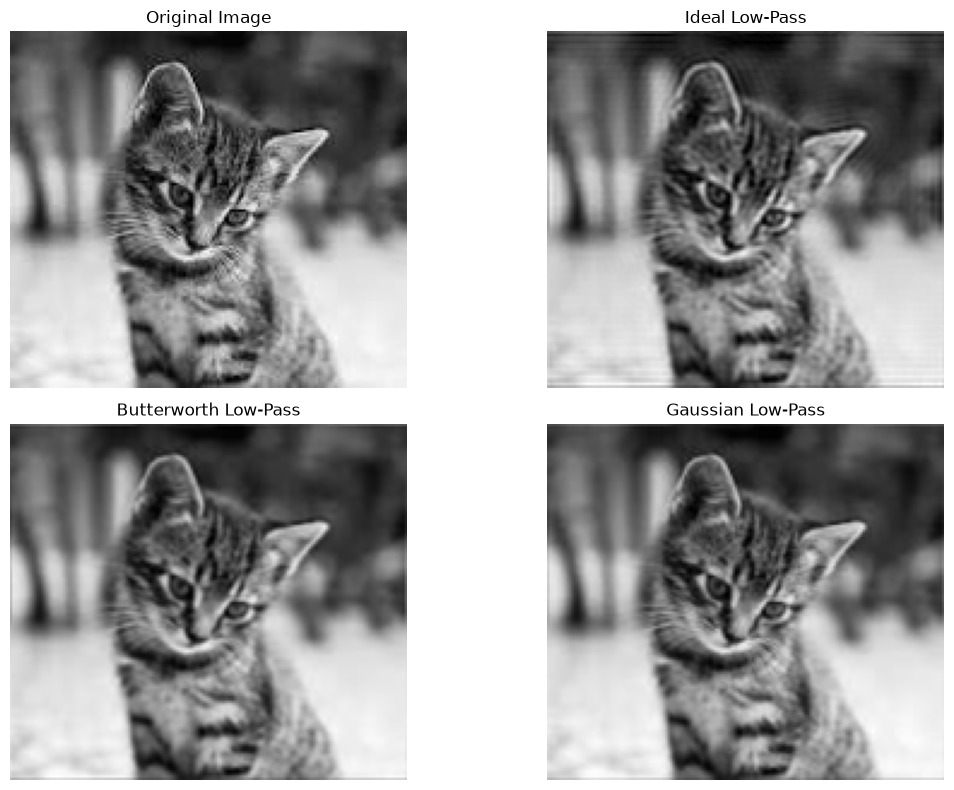

In [7]:
# ==========================================
# Display Low-Pass Results
# ==========================================

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(ideal_low, cmap="gray")
plt.title("Ideal Low-Pass")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(butterworth_low, cmap="gray")
plt.title("Butterworth Low-Pass")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gaussian_low, cmap="gray")
plt.title("Gaussian Low-Pass")
plt.axis("off")

plt.tight_layout()
plt.show()


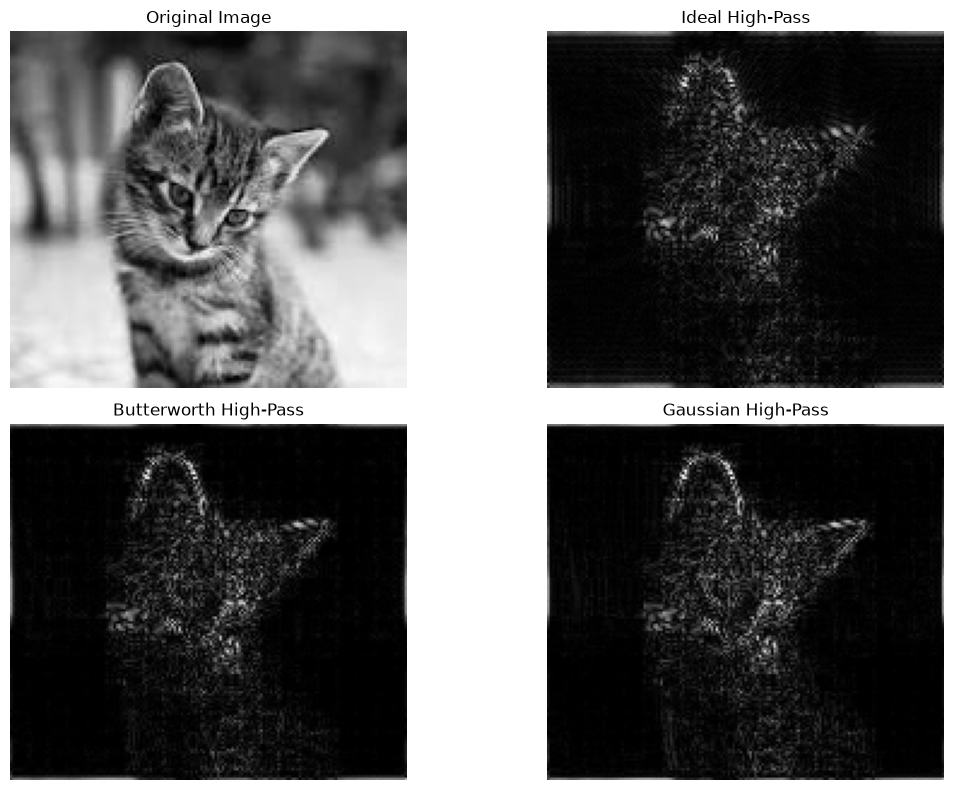

In [8]:
# ==========================================
# Display High-Pass Results
# ==========================================

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(ideal_high, cmap="gray")
plt.title("Ideal High-Pass")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(butterworth_high, cmap="gray")
plt.title("Butterworth High-Pass")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gaussian_high, cmap="gray")
plt.title("Gaussian High-Pass")
plt.axis("off")

plt.tight_layout()
plt.show()